# Pandas для менеджера: основы анализа данных

**Модуль 2, Урок 2.3** — Принятие решений на основе данных и ИИ

В этом ноутбуке мы разберём базовые приёмы работы с библиотекой **pandas** на примере датасета e-commerce продаж (48 тыс. заказов за 2024 год). Вы научитесь:

1. Загружать и осматривать данные
2. Считать частоты и доли
3. Фильтровать строки по условиям
4. Группировать и агрегировать
5. Очищать данные от мусора
6. Создавать новые столбцы
7. Визуализировать результаты

---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('pandas', pd.__version__)

pandas 3.0.3


---
## 1. Загрузка данных

Начнём с самого простого — загрузим CSV-файл с данными о продажах интернет-магазина.

In [5]:
df = pd.read_csv('../shared/data/sales_data.csv')

print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')

Размер датасета: 47929 строк, 10 столбцов


### Что мы видим

Датасет содержит **47 929 строк** (заказов) и **10 столбцов**. Каждая строка — отдельная позиция в заказе с информацией о клиенте, канале привлечения, товаре и выручке.

---
## 2. Первый осмотр

Прежде чем анализировать, нужно понять, что внутри. Четыре базовых команды для первого знакомства.

In [3]:
# Первые 10 строк — смотрим на структуру
df.head(10)

,order_id,date,customer_id,city,channel,product_category,product,quantity,price,revenue
0,10090,2024-01-01,C0127,Москва,Соцсети,Продукты,Чай,1,710.00,710.00
1,10046,2024-01-01,C0355,Челябинск,Реклама,Книги,Учебник,3,710.00,"2,130.00"
2,10002,2024-01-01,C1992,Санкт-Петербург,Реклама,Дом и сад,Кашпо,1,"4,800.00","4,800.00"
3,10038,2024-01-01,C0176,Москва,Органика,Продукты,Чай,1,"1,140.00","1,140.00"
4,10059,2024-01-01,C0034,Челябинск,Органика,Красота,Маска,5,"1,930.00","9,650.00"
5,10020,2024-01-01,C0333,Нижний Новгород,Реклама,Книги,Нон-фикшн,1,"1,790.00","1,790.00"
6,10019,2024-01-01,C0068,Москва,Органика,Красота,Крем,1,"3,850.00","3,850.00"
7,10021,2024-01-01,C0161,Москва,Реклама,Продукты,Кофе,1,430.00,430.00
8,10051,2024-01-01,C1766,Казань,Соцсети,Одежда,Футболка,1,"9,490.00","9,490.00"
9,10023,2024-01-01,C1200,Москва,Email,Электроника,Колонка,1,"2,720.00","2,720.00"


### Что мы видим

Каждая строка — позиция заказа. Столбцы: идентификаторы (`order_id`, `customer_id`), география (`city`), маркетинг (`channel`), товар (`product_category`, `product`), количество и деньги (`quantity`, `price`, `revenue`). Даты идут с 2024-01-01.

In [4]:
# Статистика по числовым столбцам
df.describe()

,order_id,quantity,price,revenue
count,"47,929.00","47,929.00","47,929.00","47,929.00"
mean,"33,508.95",1.74,"3,590.49","6,257.05"
std,"13,561.75",1.12,"2,736.37","6,962.68"
min,"10,001.00",1.00,"-10,950.00","-56,050.00"
25%,"21,770.00",1.00,"1,530.00","2,010.00"
50%,"33,515.00",1.00,"2,820.00","4,120.00"
75%,"45,252.00",2.00,"5,120.00","7,760.00"
max,"56,995.00",5.00,"12,000.00","59,900.00"


### Что мы видим

- Среднее количество товаров в позиции — **1.7 шт.**, максимум — 5.
- Средний чек позиции (revenue) — **6 257 руб.**, медиана — 4 120 руб. Распределение смещено вправо: есть крупные заказы.
- **Внимание**: минимальная цена **отрицательная** (−10 950) — скорее всего, это возвраты. Их нужно будет обработать.

In [ ]:
# Информация о типах и пропусках
df.info()

### Что мы видим

- Столбец `date` загрузился как `object` (текст), а не дата — позже сконвертируем.
- В столбце `city` только **47 451** непустых значений из 47 929 — то есть **478 пропусков** (1%). Нужно решить, что с ними делать.
- Остальные столбцы без пропусков.

In [5]:
# Типы данных — компактный обзор
df.dtypes

order_id              int64
date                    str
customer_id             str
city                    str
channel                 str
product_category        str
product                 str
quantity              int64
price               float64
revenue             float64
dtype: object

### Что мы видим

Числовые столбцы (`quantity`, `price`, `revenue`) корректно распознаны как `int64` / `float64`. Текстовые — как `object`. Столбец `date` пока текст — это типичная ситуация при загрузке CSV.

---
## 3. Частоты

Когда мы поняли структуру, следующий шаг — посмотреть распределения категориальных переменных.

In [7]:
# Топ-10 городов по числу заказов
df['city'].value_counts().head(20)

city
Москва             16517
Санкт-Петербург     7851
Казань              4151
Новосибирск         3603
Екатеринбург        2633
Краснодар           2604
Нижний Новгород     2567
Самара              2030
Ростов-на-Дону      1557
Воронеж             1543
Челябинск           1362
Пермь               1033
Name: count, dtype: int64

### Что мы видим

**Москва = 35% заказов**, Санкт-Петербург — 17%. Два города дают больше половины всех заказов. Остальные 8 городов суммарно — менее 50%. Типичная картина для российского e-commerce.

In [8]:
# Каналы привлечения — доли
df['channel'].value_counts(normalize=True).mul(100).round(1)

channel
Реклама    35.20
Органика   29.90
Email      15.30
Соцсети    11.60
Реферал     8.00
Name: proportion, dtype: float64

### Что мы видим

Топ-канал — **Реклама (35%)**, на втором месте **Органика (30%)**. Вместе они дают 65% трафика. Email (15%) и Соцсети (12%) — заметные, но вторичные каналы. Реферальная программа (8%) — самая маленькая доля.

In [9]:
# Категории товаров
df['product_category'].value_counts()

product_category
Электроника    11956
Одежда         10695
Книги           7146
Дом и сад       6258
Спорт           4710
Красота         3886
Продукты        3278
Name: count, dtype: int64

### Что мы видим

Лидер по числу заказов — **Электроника** (~12 тыс.), за ней **Одежда** (~10.7 тыс.). Остальные категории (Книги, Дом и сад, Спорт, Красота, Продукты) значительно меньше. Но число заказов — это ещё не выручка; дальше проверим, кто приносит больше денег.

---
## 4. Фильтрация

Одна из самых частых задач — отобрать строки по условию. Pandas использует для этого булеву индексацию.

In [10]:
# Простое условие: заказы из Москвы
moscow = df[df['city'] == 'Москва']
print(f'Заказов из Москвы: {len(moscow)} ({len(moscow)/len(df)*100:.1f}%)')

Заказов из Москвы: 16517 (34.5%)


In [11]:
# Комбинированное условие: крупные заказы из рекламы
# Выручка > 10 000 И канал = Реклама
big_ads = df[(df['revenue'] > 10_000) & (df['channel'] == 'Реклама')]
print(f'Крупных рекламных заказов (>10К): {len(big_ads)}')
print(f'Их суммарная выручка: {big_ads["revenue"].sum():,.0f} руб.')

Крупных рекламных заказов (>10К): 2920
Их суммарная выручка: 52,738,540 руб.


In [12]:
# Условие ИЛИ: Москва или Санкт-Петербург
capitals = df[(df['city'] == 'Москва') | (df['city'] == 'Санкт-Петербург')]
print(f'Заказов из двух столиц: {len(capitals)} ({len(capitals)/len(df)*100:.1f}%)')

Заказов из двух столиц: 24368 (50.8%)


In [13]:
# Выбор конкретных столбцов
df[['city', 'channel', 'revenue']].head(5)

,city,channel,revenue
0,Москва,Соцсети,710.00
1,Челябинск,Реклама,"2,130.00"
2,Санкт-Петербург,Реклама,"4,800.00"
3,Москва,Органика,"1,140.00"
4,Челябинск,Органика,"9,650.00"


In [14]:
# Текстовый поиск: товары, содержащие слово «Наушники»
headphones = df[df['product'].str.contains('Наушники', na=False)]
print(f'Позиций с наушниками: {len(headphones)}')
headphones[['product', 'price', 'revenue']].head(5)

Позиций с наушниками: 2396


,product,price,revenue
14,Наушники,"1,910.00","3,820.00"
32,Наушники,"3,130.00","6,260.00"
33,Наушники,"2,980.00","14,900.00"
34,Наушники,"1,980.00","3,960.00"
37,Наушники,"5,400.00","16,200.00"


### Что мы видим

Фильтрация позволяет быстро выделять сегменты. Ключевые приёмы:
- **Одно условие**: `df[df['column'] == value]`
- **И**: `df[(cond1) & (cond2)]` — скобки обязательны!
- **ИЛИ**: `df[(cond1) | (cond2)]`
- **Текстовый поиск**: `str.contains()` — ищет подстроку
- **Выбор столбцов**: `df[['col1', 'col2']]` — двойные скобки

---
## 5. Группировка

Группировка — главный инструмент менеджера. Она отвечает на вопросы вроде «Сколько выручки приносит каждый город?» или «Какой средний чек по каналам?».

In [15]:
# Выручка по городам — топ-5
city_revenue = df.groupby('city')['revenue'].sum().sort_values(ascending=False)
city_revenue.head(5)

city
Москва            104,158,400.00
Санкт-Петербург    48,423,170.00
Казань             26,474,030.00
Новосибирск        22,756,340.00
Екатеринбург       16,452,250.00
Name: revenue, dtype: float64

### Что мы видим

**Москва приносит 35% выручки** (~104 млн руб.), Санкт-Петербург — 16% (~48 млн). Два города генерируют более половины всей выручки магазина.

In [6]:
# Средний чек по каналам
df.groupby('channel')['revenue'].mean().sort_values(ascending=False)

channel
Реферал    6,556.24
Email      6,328.24
Органика   6,261.18
Реклама    6,182.56
Соцсети    6,173.19
Name: revenue, dtype: float64

### Что мы видим

Средний чек по каналам отличается не так сильно, как объём. Это значит, что каналы различаются прежде всего **количеством клиентов**, а не их качеством (размером чека).

In [7]:
# Несколько агрегаций сразу
channel_stats = df.groupby('channel')['revenue'].agg(
    заказов='count',
    выручка='sum',
    средний_чек='mean',
    медиана='median'
).sort_values('выручка', ascending=False)

channel_stats

,заказов,выручка,средний_чек,медиана
channel,,,,
Реклама,16860,"104,237,980.00","6,182.56","4,020.00"
Органика,14333,"89,741,450.00","6,261.18","4,200.00"
Email,7352,"46,525,210.00","6,328.24","4,075.00"
Соцсети,5572,"34,397,040.00","6,173.19","4,020.00"
Реферал,3812,"24,992,380.00","6,556.24","4,400.00"


In [8]:
# Топ-5 самых популярных товаров по каждому региону (городу)
# Популярность считаем как суммарное количество проданных штук (quantity)

top5_by_region = (
    df.groupby(['city', 'product'])['quantity']
      .sum()                                   # сколько штук каждого товара продано в городе
      .reset_index(name='units_sold')
      .sort_values(['city', 'units_sold'], ascending=[True, False])
      .groupby('city')
      .head(5)                                 # берём топ-5 в каждом городе
      .reset_index(drop=True)
)

# Добавим ранг внутри города (1 = самый популярный)
top5_by_region['rank'] = top5_by_region.groupby('city').cumcount() + 1

# Удобный вид: города в строках, ранг в колонках
top5_pivot = top5_by_region.pivot(index='city', columns='rank', values='product')
top5_pivot.columns = [f'#{i}' for i in top5_pivot.columns]

print('Топ-5 товаров по каждому региону (по количеству проданных штук):\n')
top5_pivot


Топ-5 товаров по каждому региону (по количеству проданных штук):



,#1,#2,#3,#4,#5
city,,,,,
Воронеж,Наушники,Куртка,Кабель USB,Футболка,Зарядка
Екатеринбург,Зарядка,Колонка,Рюкзак,Наушники,Кабель USB
Казань,Колонка,Кабель USB,Наушники,Чехол,Зарядка
Краснодар,Кабель USB,Зарядка,Кроссовки,Чехол,Джинсы
Москва,Колонка,Наушники,Кабель USB,Зарядка,Чехол
Нижний Новгород,Рюкзак,Кроссовки,Наушники,Колонка,Зарядка
Новосибирск,Наушники,Колонка,Куртка,Кабель USB,Чехол
Пермь,Чехол,Зарядка,Наушники,Колонка,Кабель USB
Ростов-на-Дону,Колонка,Куртка,Чехол,Кабель USB,Кроссовки


### Что мы видим

Реклама лидирует и по выручке (35%), и по количеству заказов. Но средний чек по каналам примерно одинаковый — около 6 000-6 500 руб. Главное различие каналов — объём трафика, а не его качество.

In [12]:
# Группировка по двум столбцам: город + категория
city_cat = df.groupby(['city', 'product_category'])['revenue'].sum().reset_index()
city_cat_top = city_cat[city_cat['city'] == 'Москва'].sort_values('revenue', ascending=False)
city_cat_top.head(5)

,city,product_category,revenue
31,Москва,Одежда,"40,530,150.00"
34,Москва,Электроника,"30,499,610.00"
28,Москва,Дом и сад,"11,865,530.00"
33,Москва,Спорт,"7,547,730.00"
29,Москва,Книги,"6,061,120.00"


In [13]:
# Сводная таблица: средняя выручка по городам и каналам
pivot = pd.pivot_table(
    df,
    values='revenue',
    index='city',
    columns='channel',
    aggfunc='mean'
)
pivot.head(5)

channel,Email,Органика,Реклама,Реферал,Соцсети
city,,,,,
Воронеж,"5,432.43","5,869.64","6,025.96","6,732.95","7,134.07"
Екатеринбург,"5,714.37","6,119.03","6,315.23","6,996.59","6,615.86"
Казань,"6,563.58","6,358.73","6,153.21","7,171.97","6,320.80"
Краснодар,"6,611.40","6,065.42","6,073.91","6,578.20","6,159.68"
Москва,"6,445.29","6,394.66","6,207.65","6,413.39","6,121.95"


### Что мы видим

Сводная таблица (pivot table) — аналог сводных в Excel. Позволяет одним вызовом увидеть пересечение двух измерений. Здесь мы видим средний чек по каждому городу и каналу — можно искать аномалии и точки роста.

---
## 6. Очистка данных

Реальные данные всегда грязные. Pandas даёт набор инструментов для приведения данных в порядок.

In [14]:
# Дубликаты
print(f'Строк до очистки: {len(df)}')
print(f'Дубликатов: {df.duplicated().sum()}')

df_clean = df.drop_duplicates()
print(f'Строк после удаления дубликатов: {len(df_clean)}')

Строк до очистки: 47929
Дубликатов: 934
Строк после удаления дубликатов: 46995


### Что мы видим

В данных **934 полных дубликата** (2%). Это могут быть ошибки импорта или повторные записи. После `drop_duplicates()` осталось ~46 995 уникальных строк.

In [15]:
# Пропуски — заполняем город значением «Неизвестно»
print(f'Пропусков в city до: {df_clean["city"].isna().sum()}')

df_clean = df_clean.copy()
df_clean['city'] = df_clean['city'].fillna('Неизвестно')

print(f'Пропусков в city после: {df_clean["city"].isna().sum()}')

Пропусков в city до: 467
Пропусков в city после: 0


In [29]:
# Конвертация даты из текста
print(f'Тип date до: {df_clean["date"].dtype}')

df_clean['date'] = pd.to_datetime(df_clean['date'])

print(f'Тип date после: {df_clean["date"].dtype}')
print(f'Диапазон: {df_clean["date"].min().date()} — {df_clean["date"].max().date()}')

Тип date до: datetime64[us]
Тип date после: datetime64[us]
Диапазон: 2024-01-01 — 2024-12-31


In [17]:
# Очистка текста — убираем пробелы (пример)
# str.strip() удаляет пробелы в начале и конце строки
df_clean['product'] = df_clean['product'].str.strip()
df_clean['city'] = df_clean['city'].str.strip()

print(f'Уникальных товаров: {df_clean["product"].nunique()}')
print(f'Уникальных городов: {df_clean["city"].nunique()}')

Уникальных товаров: 35
Уникальных городов: 13


In [18]:
# Безопасная конвертация в число — to_numeric с errors='coerce'
# (полезно когда в столбце могут быть текстовые значения)
df_clean['revenue'] = pd.to_numeric(df_clean['revenue'], errors='coerce')

print(f'Новых NaN в revenue: {df_clean["revenue"].isna().sum()}')

Новых NaN в revenue: 0


### Что мы видим

После очистки:
- Удалено **934 дубликата**
- **478 пропусков** в городе заполнены значением «Неизвестно»
- Дата сконвертирована из текста — теперь можно извлекать месяц, день недели
- Текстовые поля очищены от лишних пробелов

Дальше работаем с очищенным датафреймом `df_clean`.

---
## 7. Новые столбцы

Часто нужно создать расчётные поля — маржу, сегмент, месяц. Pandas делает это просто.

In [19]:
# Арифметика: средняя цена за единицу
df_clean['unit_price'] = df_clean['revenue'] / df_clean['quantity']
df_clean[['product', 'quantity', 'revenue', 'unit_price']].head(5)

,product,quantity,revenue,unit_price
0,Чай,1,710.00,710.00
1,Учебник,3,"2,130.00",710.00
2,Кашпо,1,"4,800.00","4,800.00"
3,Чай,1,"1,140.00","1,140.00"
4,Маска,5,"9,650.00","1,930.00"


In [20]:
# Извлечение месяца из даты
df_clean['month'] = df_clean['date'].dt.month
df_clean['month_name'] = df_clean['date'].dt.strftime('%B')

df_clean[['date', 'month', 'month_name']].head(5)

,date,month,month_name
0,2024-01-01,1,January
1,2024-01-01,1,January
2,2024-01-01,1,January
3,2024-01-01,1,January
4,2024-01-01,1,January


In [21]:
# Сегментация с pd.cut — размер заказа
df_clean['order_size'] = pd.cut(
    df_clean['revenue'],
    bins=[-np.inf, 2000, 5000, 10000, np.inf],
    labels=['Мелкий (<2K)', 'Средний (2-5K)', 'Крупный (5-10K)', 'VIP (>10K)']
)

df_clean['order_size'].value_counts()

order_size
Средний (2-5K)     15638
Мелкий (<2K)       11666
Крупный (5-10K)    11450
VIP (>10K)          8241
Name: count, dtype: int64

In [22]:
# Условный столбец с np.where
df_clean['is_return'] = np.where(df_clean['revenue'] < 0, 'Возврат', 'Покупка')

print(df_clean['is_return'].value_counts())
print(f'\nДоля возвратов: {(df_clean["is_return"] == "Возврат").mean()*100:.2f}%')

is_return
Покупка    46772
Возврат      223
Name: count, dtype: int64

Доля возвратов: 0.47%


### Что мы видим

Мы создали четыре новых столбца:
- `unit_price` — цена за единицу (арифметика)
- `month` — номер месяца из даты (`.dt.month`)
- `order_size` — сегмент по размеру чека (`pd.cut`)
- `is_return` — флаг возврата (`np.where`)

Отрицательная выручка — возвраты. Их немного, но они влияют на итоги.

---
## 8. Визуализация (matplotlib)

Графики помогают увидеть закономерности, которые теряются в таблицах.

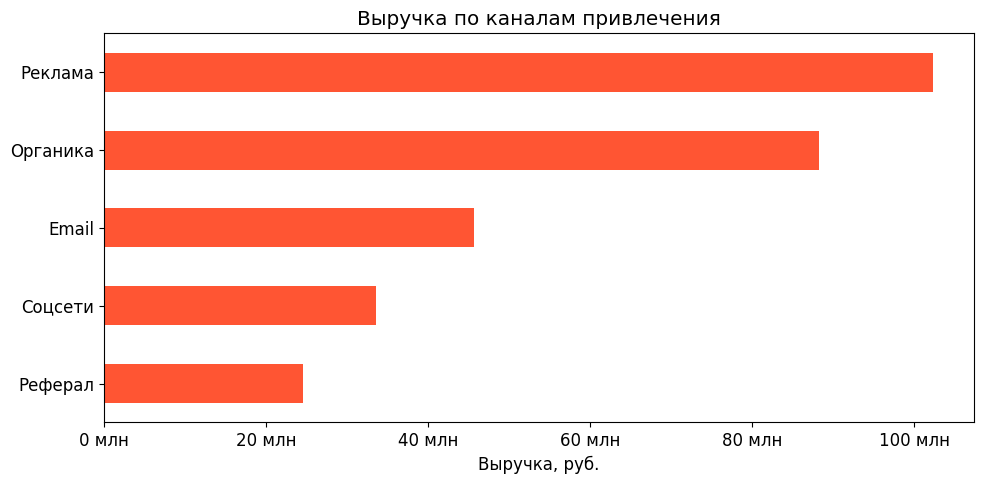

In [23]:
# Столбчатая диаграмма: выручка по каналам
channel_rev = df_clean.groupby('channel')['revenue'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
channel_rev.plot.barh(ax=ax, color='#ff5533')
ax.set_xlabel('Выручка, руб.')
ax.set_ylabel('')
ax.set_title('Выручка по каналам привлечения')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f} млн'))
plt.tight_layout()
plt.savefig('channel_revenue_bar.png', dpi=150, bbox_inches='tight')
plt.show()

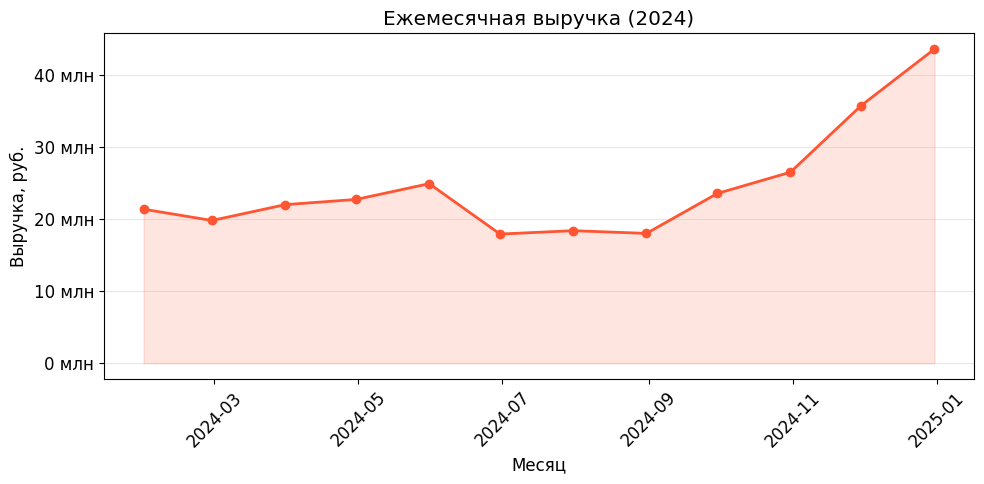

In [24]:
# Линейный график: ежемесячная выручка
monthly_rev = df_clean.set_index('date')['revenue'].resample('ME').sum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_rev.index, monthly_rev.values, color='#ff5533', linewidth=2, marker='o', markersize=6)
ax.fill_between(monthly_rev.index, monthly_rev.values, alpha=0.15, color='#ff5533')
ax.set_xlabel('Месяц')
ax.set_ylabel('Выручка, руб.')
ax.set_title('Ежемесячная выручка (2024)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f} млн'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Что мы видим

Линейный тренд показывает динамику выручки по месяцам. Можно заметить сезонные колебания — важно для планирования маркетинговых бюджетов и закупок.

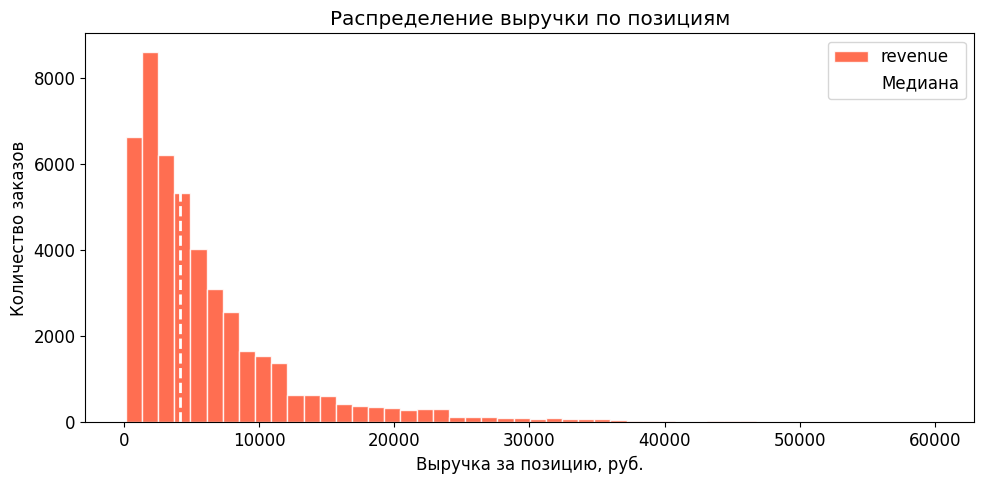

In [25]:
# Гистограмма: распределение размера заказа
fig, ax = plt.subplots(figsize=(10, 5))
df_clean[df_clean['revenue'] > 0]['revenue'].plot.hist(
    bins=50, ax=ax, color='#ff5533', edgecolor='white', alpha=0.85
)
ax.set_xlabel('Выручка за позицию, руб.')
ax.set_ylabel('Количество заказов')
ax.set_title('Распределение выручки по позициям')
ax.axvline(df_clean[df_clean['revenue'] > 0]['revenue'].median(), color='white',
           linestyle='--', linewidth=2, label='Медиана')
ax.legend()
plt.tight_layout()
plt.savefig('revenue_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

### Что мы видим

Распределение выручки **смещено вправо** (правая асимметрия): большинство позиций — мелкие (до 5 тыс. руб.), но есть длинный хвост крупных заказов. Медиана (~4 100 руб.) меньше среднего (~6 300 руб.) — классический признак скошенного распределения.

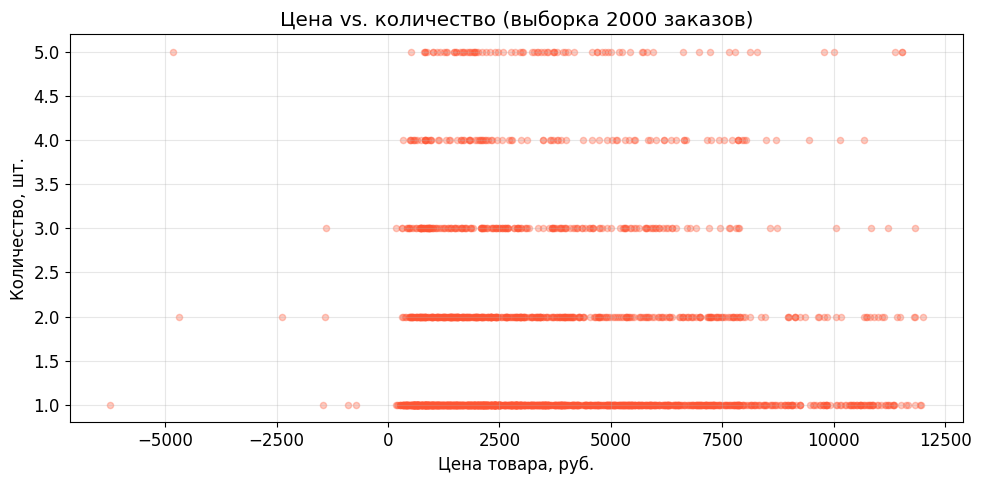

In [26]:
# Scatter: цена vs. количество
sample = df_clean[df_clean['revenue'] > 0].sample(2000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample['price'], sample['quantity'], alpha=0.3, color='#ff5533', s=20)
ax.set_xlabel('Цена товара, руб.')
ax.set_ylabel('Количество, шт.')
ax.set_title('Цена vs. количество (выборка 2000 заказов)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('price_quantity_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Что мы видим

Scatter plot показывает, что дорогие товары чаще покупают по 1 штуке, а дешёвые — по несколько. Это логично: чем дороже товар, тем реже берут несколько единиц.

---
## 9. Визуализация (seaborn)

Seaborn — надстройка над matplotlib с более красивыми графиками и удобным синтаксисом для статистических визуализаций.

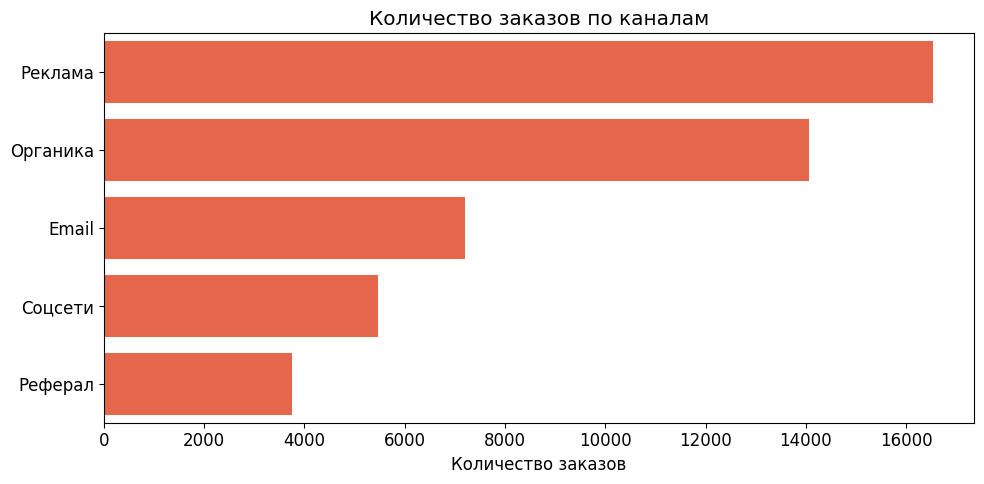

In [27]:
# Countplot: количество заказов по каналам
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(
    data=df_clean,
    y='channel',
    order=df_clean['channel'].value_counts().index,
    color='#ff5533',
    ax=ax
)
ax.set_xlabel('Количество заказов')
ax.set_ylabel('')
ax.set_title('Количество заказов по каналам')
plt.tight_layout()
plt.savefig('seaborn_countplot.png', dpi=150, bbox_inches='tight')
plt.show()

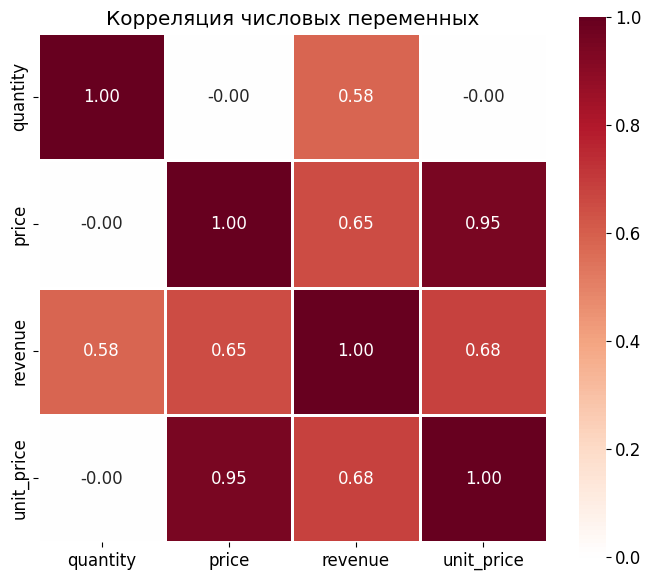

In [28]:
# Heatmap: корреляция числовых столбцов
numeric_cols = ['quantity', 'price', 'revenue', 'unit_price']
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdGy_r',
    center=0,
    square=True,
    linewidths=1,
    ax=ax
)
ax.set_title('Корреляция числовых переменных')
plt.tight_layout()
plt.savefig('seaborn_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Что мы видим

Корреляционная матрица показывает связи между числовыми переменными:
- `revenue` сильно коррелирует с `price` — ожидаемо, выручка = цена x количество
- `quantity` коррелирует с `revenue` слабее — количество не так сильно влияет на выручку, как цена товара

In [ ]:
# Boxplot: распределение выручки по категориям товаров
positive_orders = df_clean[df_clean['revenue'] > 0]

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=positive_orders,
    x='product_category',
    y='revenue',
    hue='product_category',
    palette=['#ff5533', '#ff7755', '#ff9977', '#ffbb99', '#cc4422', '#993311', '#662200'],
    legend=False,
    ax=ax
)
ax.set_xlabel('Категория товара')
ax.set_ylabel('Выручка, руб.')
ax.set_title('Распределение выручки по категориям')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('seaborn_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Что мы видим

Boxplot показывает медиану, квартили и выбросы для каждой категории. Электроника имеет самый широкий разброс — от дешёвых аксессуаров до дорогих гаджетов. Книги и Продукты — более компактные распределения с низкими чеками.

In [ ]:
# Pairplot: попарные зависимости (на выборке для скорости)
sample_for_pair = df_clean[df_clean['revenue'] > 0][['quantity', 'price', 'revenue']].sample(
    1000, random_state=42
)

g = sns.pairplot(
    sample_for_pair,
    plot_kws={'alpha': 0.3, 'color': '#ff5533', 's': 15},
    diag_kws={'color': '#ff5533', 'alpha': 0.7}
)
g.figure.suptitle('Попарные зависимости (выборка 1000)', y=1.02)
plt.tight_layout()
plt.savefig('seaborn_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Что мы видим

Pairplot даёт полную картину попарных зависимостей. На диагонали — гистограммы каждой переменной. На остальных панелях — scatter plots. Видна сильная линейная связь price-revenue и дискретная природа quantity (только целые числа 1-5).

---
## 10. Ключевые выводы

По результатам анализа 48 тыс. заказов e-commerce за 2024 год:

### 1. Концентрация выручки в Москве
**Москва генерирует 35% выручки** (~104 млн руб.). Вместе с Санкт-Петербургом — более 51%. Решения по ассортименту и логистике должны ориентироваться на эти два города в первую очередь.

### 2. Реклама — главный канал, но органика рядом
Реклама приносит 35% выручки, органика — 30%. При этом средний чек по каналам **примерно одинаковый** (~6 300 руб.). Рост органики может существенно снизить стоимость привлечения без потери качества клиентов.

### 3. Правая асимметрия чеков
Медиана выручки (4 100 руб.) значительно ниже среднего (6 300 руб.). Небольшая доля крупных заказов (>10 тыс. руб.) существенно влияет на общую выручку. Стоит отдельно работать с VIP-сегментом.

### 4. Данные требуют очистки
Обнаружено **934 дубликата** (2%) и **478 пропусков** в городе (1%). Есть **отрицательные значения** выручки (возвраты). Без очистки эти проблемы искажают аналитику.

### 5. Электроника — лидер по объёму и разбросу
Электроника занимает первое место по числу заказов (~12 тыс.) и имеет самый широкий разброс чеков. Это и самая перспективная, и самая рискованная категория с точки зрения маржинальности.